<a href="https://colab.research.google.com/github/ZahranAzariaAnvaya/BigData26_A_2411531005_ZahranAzariaAnvaya/blob/main/Praktikum4/BD_A_P04_2411531005_Zahran_Azaria_Anvaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum**







## **K-1. Menyiapkan Lingkungan dan Data Contoh**

Sel ini memasang pustaka, menghubungkan Google Drive, menentukan folder `trips_bersih/` hasil Praktikum 3 sebagai sumber, dan membuat folder `Praktikum4` untuk hasil. `assert` menghentikan sel bila folder sumber tidak ada, supaya kesalahan path langsung ketahuan.

In [ ]:
!pip install -q duckdb networkx shapely tinydb "deltalake>=1.0"

from google.colab import drive
drive.mount("/content/drive")

DIR_P3 = "/content/drive/MyDrive/BigData/Praktikum3"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum4"
TRIPS_BERSIH = f"{DIR_P3}/trips_bersih"    # hasil Praktikum 3 (K-10)

import os
os.makedirs(DIR_SIMPAN, exist_ok=True)
assert os.path.exists(TRIPS_BERSIH), "Folder trips_bersih/ tidak ada. Jalankan ulang P3/K-10 atau pakai K-1b."

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Sel ini mendefinisikan `ukur()` untuk mencatat waktu tiap percobaan ke list `catatan`, membaca seluruh `trips_bersih/` ke `df`, lalu mengganti nama kolom TLC menjadi nama yang mudah dibaca (`NAMA_BARU`). Terakhir diambil contoh 300.000 baris (`sample`) dengan kolom `id_perjalanan` untuk K-2 dan K-3.

In [ ]:
import os, time, json, sqlite3, random, shutil, glob
import numpy as np, pandas as pd
import pyarrow.dataset as ds

# Pengukur waktu (dari Praktikum 1/K-3, versi ringkas)
catatan = []
def ukur(label, fungsi):
    t0 = time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 4)})
    print(f"[{label}] {detik:.4f} s")
    return hasil

df = ukur("baca trips_bersih",
          lambda: ds.dataset(TRIPS_BERSIH, format="parquet", partitioning="hive").to_table().to_pandas())

# Ganti nama kolom asli data TLC menjadi nama yang lebih mudah dibaca
NAMA_BARU = {
    "tpep_pickup_datetime": "waktu_jemput",
    "PULocationID": "zona_jemput",
    "DOLocationID": "zona_tujuan",
    "borough_naik": "wilayah_jemput",
    "trip_distance": "jarak_mil",
    "total_amount": "total_bayar",
    "tip_amount": "tip",
    "nama_pembayaran": "metode_bayar",
}

df = df.rename(columns=NAMA_BARU)
df["wilayah_jemput"] = df["wilayah_jemput"].astype(str)
print("baris:", f"{len(df):,}", "| kolom:", df.shape[1])

# Contoh 300.000 baris untuk K-2 dan K-3 (agar tidak terlalu lama)
sample = df.sample(n=min(300_000, len(df)), random_state=42).reset_index(drop=True)
sample["id_perjalanan"] = sample.index + 1
sample["waktu_jemput"] = sample["waktu_jemput"].astype(str)

[baca trips_bersih] 3.2851 s
baris: 2,986,910 | kolom: 18


## **K-2. Tabel Biasa vs Key-value**

Perjalanan yang sama disimpan dalam dua cara: tabel SQLite (relasional) dan kamus Python berkunci `perjalanan:<id>` bernilai teks JSON (key-value). Dua pertanyaan diajukan: (A) ambil satu perjalanan berdasarkan id, dan (B) hitung rata-rata `total_bayar` per wilayah. Pertanyaan A diukur tanpa indeks, dengan indeks, dan di key-value.

**Dugaan:** pada pertanyaan A, tabel tanpa indeks paling lambat (kira-kira ratusan kali lipat dibanding yang berindeks), sedangkan tabel berindeks dan key-value nyaris sama cepat. Pada pertanyaan B, SQL `GROUP BY` menang dan key-value kira-kira 5–10 kali lebih lambat karena setiap nilai harus dibuka dulu.

In [ ]:
KOLOM = ["id_perjalanan", "waktu_jemput", "zona_jemput", "zona_tujuan",
         "wilayah_jemput", "jarak_mil", "total_bayar", "metode_bayar"]
data = sample[KOLOM].copy()

# Model 1 - relasional: tabel SQLite
if os.path.exists("uji.db"):
    os.remove("uji.db")
con = sqlite3.connect("uji.db")
ukur("relasional: muat tabel", lambda: data.to_sql("perjalanan", con, index=False))

# Model 2 - key-value: kamus (dict) dengan kunci "perjalanan:<id>", nilainya teks JSON
def bangun_kv():
    return {f"perjalanan:{r['id_perjalanan']}": json.dumps(r) for r in data.to_dict("records")}

kv = ukur("key-value: bangun dict", bangun_kv)
print("jumlah key:", len(kv))

# Pertanyaan A: ambil SATU perjalanan berdasarkan id (200 id acak)
random.seed(42)
id_uji = random.sample(range(1, len(data) + 1), 200)

def cari_sql():
    cur = con.cursor()
    return [cur.execute("SELECT * FROM perjalanan WHERE id_perjalanan = ?", (i,)).fetchone() for i in id_uji]

def cari_kv():
    return [json.loads(kv[f"perjalanan:{i}"]) for i in id_uji]

r1 = ukur("cari 200 perjalanan - SQL tanpa indeks", cari_sql)
con.execute("CREATE INDEX idx_id ON perjalanan(id_perjalanan)")    # buat indeks
r2 = ukur("cari 200 perjalanan - SQL dengan indeks", cari_sql)
r3 = ukur("cari 200 perjalanan - key-value", cari_kv)
print("hasil sama?", r1[0][0] == r2[0][0] == r3[0]["id_perjalanan"])

# Pertanyaan B: hitung rata-rata total bayar per wilayah (melibatkan SEMUA data)
def hitung_sql():
    return con.execute("""SELECT wilayah_jemput, COUNT(*), ROUND(AVG(total_bayar), 2)
                          FROM perjalanan GROUP BY wilayah_jemput ORDER BY 2 DESC, 1""").fetchall()

def hitung_kv():
    total, jumlah = {}, {}
    for teks in kv.values():
        d = json.loads(teks)              # setiap nilai harus dibuka dulu
        w = d["wilayah_jemput"]
        total[w] = total.get(w, 0) + d["total_bayar"]
        jumlah[w] = jumlah.get(w, 0) + 1
    return sorted([(w, jumlah[w], round(total[w] / jumlah[w], 2)) for w in jumlah],
                  key=lambda x: (-x[1], x[0]))

h1 = ukur("hitung per wilayah - SQL GROUP BY", hitung_sql)
h2 = ukur("hitung per wilayah - key-value (buka semua nilai)", hitung_kv)
print(h1[:3])
print("hasil sama?", h1 == h2)

[relasional: muat tabel] 2.0738 s
[key-value: bangun dict] 7.7187 s
jumlah key: 300000
[cari 200 perjalanan - SQL tanpa indeks] 9.3578 s
[cari 200 perjalanan - SQL dengan indeks] 0.0037 s
[cari 200 perjalanan - key-value] 0.0013 s
hasil sama? True
[hitung per wilayah - SQL GROUP BY] 0.2021 s
[hitung per wilayah - key-value (buka semua nilai)] 1.3054 s
[('Manhattan', 267034, 22.7), ('Queens', 27288, 70.34), ('Unknown', 3787, 39.13)]
hasil sama? True


## **K-3. Document: Bentuk Data yang Fleksibel**

Perjalanan disimpan sebagai dokumen JSON bersarang di TinyDB (document store). Data terkait dibungkus dalam satu dokumen (*embedding*), dan field `tip` sengaja hanya ada pada pembayaran kartu, seperti data TLC asli. Sel ini mengubah 20.000 baris menjadi dokumen dan mencetak satu contoh.

**Dugaan:** sekitar dua pertiga sampai tiga perempat dokumen punya field `tip` (yaitu yang dibayar kartu), sisanya tidak.

In [ ]:
from tinydb import TinyDB, Query
from tinydb.storages import MemoryStorage

def ke_dokumen(r):
    dok = {
        "id_perjalanan": int(r.id_perjalanan),
        "waktu_jemput": r.waktu_jemput,
        "jemput": {"zona": int(r.zona_jemput), "wilayah": r.wilayah_jemput},
        "tujuan": {"zona": int(r.zona_tujuan)},
        "biaya": {"jarak_mil": float(r.jarak_mil),
                   "total": float(r.total_bayar),
                   "metode_bayar": r.metode_bayar},
    }
    # Tip hanya dicatat untuk pembayaran kartu, field ini ada di sebagian dokumen saja
    if r.metode_bayar == "Kartu kredit":
        dok["biaya"]["tip"] = float(r.tip)
    return dok

db = TinyDB(storage=MemoryStorage)
tabel = db.table("perjalanan")
docs = [ke_dokumen(r) for r in sample.head(20_000).itertuples()]

tabel.insert_multiple(docs)
print("jumlah dokumen:", len(tabel))
print(json.dumps(tabel.all()[0], indent=2))

jumlah dokumen: 20000
{
  "id_perjalanan": 1,
  "waktu_jemput": "2023-01-16 10:40:39",
  "jemput": {
    "zona": 48,
    "wilayah": "Manhattan"
  },
  "tujuan": {
    "zona": 164
  },
  "biaya": {
    "jarak_mil": 1.55,
    "total": 19.32,
    "metode_bayar": "Kartu kredit",
    "tip": 3.22
  }
}


Tiga query dijalankan lewat `Query()`: dokumen dari Manhattan dengan total di atas 50, dokumen yang punya field `tip`, dan dokumen yang tidak punya. Lalu satu dokumen dengan field baru `cuaca` dimasukkan tanpa mengubah struktur apa pun, untuk memperlihatkan fleksibilitas skema dan sekaligus risikonya (tidak ada skema yang menegur).

In [ ]:
Q = Query()
print("jemput di Manhattan & total > 50 :",
      len(tabel.search((Q.jemput.wilayah == "Manhattan") & (Q.biaya.total > 50))))
print("dokumen yang punya field tip      :", len(tabel.search(Q.biaya.tip.exists())))
print("dokumen yang TIDAK punya tip      :", len(tabel.search(~Q.biaya.tip.exists())))

# Menambah field baru ("cuaca") pada satu dokumen - tanpa mengubah struktur apa pun
tabel.insert({"id_perjalanan": 999_999, "waktu_jemput": "2023-01-15 08:00:00",
              "jemput": {"zona": 161, "wilayah": "Manhattan"}, "tujuan": {"zona": 236},
              "biaya": {"jarak_mil": 1.2, "total": 14.5, "metode_bayar": "Kartu kredit", "tip": 3.0},
              "cuaca": {"hujan": True, "suhu_c": -2.0}})
print("dokumen yang punya field cuaca    :", len(tabel.search(Q.cuaca.exists())))
print("total dokumen sekarang            :", len(tabel))

jemput di Manhattan & total > 50 : 693
dokumen yang punya field tip      : 15906
dokumen yang TIDAK punya tip      : 4094
dokumen yang punya field cuaca    : 1
total dokumen sekarang            : 20001


## **K-4. Penyimpanan per Kolom: DuckDB pada Parquet**

DuckDB menjalankan SQL langsung pada folder Parquet berpartisi lewat sebuah *view* (jendela bernama; data tidak disalin), lalu dibandingkan dengan SQLite (penyimpanan per baris) untuk perhitungan yang sama: jumlah dan rata-rata `total_bayar` per wilayah. Sel ini juga mengukur biaya langkah "muat ke tabel" di SQLite.

**Dugaan:** DuckDB menang kira-kira 10 kali lipat atau lebih, dan tidak butuh langkah muat tabel yang di SQLite memakan waktu lebih lama daripada query-nya sendiri.

In [ ]:
import duckdb

GLOB = f"{TRIPS_BERSIH}/*/*.parquet"
con_d = duckdb.connect()

# VIEW = "jendela" bernama yang membaca Parquet langsung (tidak menyalin data).
# Di sinilah nama kolom asli TLC diberi nama yang mudah dibaca.
con_d.sql(f"""
    CREATE VIEW perjalanan AS
    SELECT tpep_pickup_datetime AS waktu_jemput,
           PULocationID         AS zona_jemput,
           DOLocationID         AS zona_tujuan,
           borough_naik         AS wilayah_jemput,
           trip_distance        AS jarak_mil,
           total_amount         AS total_bayar,
           nama_pembayaran      AS metode_bayar
    FROM read_parquet('{GLOB}', hive_partitioning=true)""")

SQL = """SELECT wilayah_jemput, COUNT(*) AS jumlah, ROUND(AVG(total_bayar), 2) AS rata_bayar
         FROM perjalanan GROUP BY wilayah_jemput ORDER BY jumlah DESC, wilayah_jemput"""
hasil_d = ukur("DuckDB - hitung per wilayah (langsung dari Parquet)", lambda: con_d.sql(SQL).df())
print(hasil_d)

# Pembanding: SQLite (menyimpan per baris) pada data yang sama
KOLOM_S = ["wilayah_jemput", "total_bayar", "jarak_mil", "zona_jemput", "zona_tujuan"]
if os.path.exists("baris.db"):
    os.remove("baris.db")
con_s = sqlite3.connect("baris.db")
ukur("SQLite - muat seluruh baris ke tabel", lambda: df[KOLOM_S].to_sql("perjalanan", con_s, index=False))
hasil_s = ukur("SQLite - hitung per wilayah", lambda: con_s.execute(
    """SELECT wilayah_jemput, COUNT(*), ROUND(AVG(total_bayar), 2)
       FROM perjalanan GROUP BY wilayah_jemput ORDER BY 2 DESC, 1""").fetchall())
print("hasil sama?", [tuple(r) for r in hasil_d.itertuples(index=False)] == [tuple(r) for r in hasil_s])

[DuckDB - hitung per wilayah (langsung dari Parquet)] 0.2551 s
               wilayah_jemput   jumlah  rata_bayar
0                   Manhattan  2659609       22.72
1                      Queens   270315       70.46
2                     Unknown    37609       39.24
3                    Brooklyn    15724       32.72
4                       Bronx     3074       34.44
5  __HIVE_DEFAULT_PARTITION__      340       74.72
6               Staten Island      211       74.07
7                         EWR       28      106.41
[SQLite - muat seluruh baris ke tabel] 8.3668 s
[SQLite - hitung per wilayah] 2.7871 s
hasil sama? False


Query difilter pada kolom partisi (`wilayah_jemput = 'Staten Island'`) sehingga DuckDB hanya membuka folder wilayah itu (*partition pruning* dari Praktikum 3). Sel ini juga membandingkan ukuran folder Parquet (semua kolom) dengan berkas SQLite (hanya 5 kolom).

In [ ]:
# Filter pada kolom partisi: DuckDB hanya membuka folder wilayah yang diminta (partition pruning, P3)
SQL2 = """SELECT COUNT(*), ROUND(AVG(total_bayar), 2)
          FROM perjalanan WHERE wilayah_jemput = 'Staten Island'"""
print(ukur("DuckDB - hanya wilayah Staten Island", lambda: con_d.sql(SQL2).fetchall()))

ukuran_pq = sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(TRIPS_BERSIH) for f in fs) / 1024**2
print(f"Parquet ({df.shape[1]} kolom): {ukuran_pq:.1f} MB | SQLite ({len(KOLOM_S)} kolom): {os.path.getsize('baris.db') / 1024**2:.1f} MB")

[DuckDB - hanya wilayah Staten Island] 0.0476 s
[(211, 74.07)]
Parquet (18 kolom): 66.5 MB | SQLite (5 kolom): 114.2 MB


## **K-5. Graph: Pertanyaan tentang Keterhubungan**

Perjalanan diringkas menjadi arus antar zona: tiap zona adalah *node*, tiap pasangan zona asal–tujuan adalah *edge* berarah dengan bobot jumlah perjalanan. Hasil graph disilangkan dengan SQL (lima arus terbesar) supaya keduanya terbukti menjawab hal yang sama. Urutan diberi pengurut tambahan (jumlah, asal, tujuan) agar pasti.

In [ ]:
import networkx as nx

# Satu baris = satu arus: berapa perjalanan dari zona jemput ke zona tujuan tertentu
arus = ukur("hitung arus antar zona", lambda: con_d.sql("""
    SELECT zona_jemput AS asal, zona_tujuan AS tujuan, COUNT(*) AS jumlah
    FROM perjalanan GROUP BY 1, 2""").df())

# Zona = node (titik), arus = edge (garis berarah, bobotnya jumlah perjalanan)
G = nx.DiGraph()
for r in arus.itertuples(index=False):
    G.add_edge(int(r.asal), int(r.tujuan), jumlah=int(r.jumlah))
print("node (zona):", G.number_of_nodes(), "| edge (arus):", G.number_of_edges())

# Lima arus terbesar. Urutan dibuat pasti dengan pengurut tambahan (jumlah, asal, tujuan)
top_graf = sorted(G.edges(data=True), key=lambda e: (-e[2]["jumlah"], e[0], e[1]))[:5]
print("graph:", [(a, b, d["jumlah"]) for a, b, d in top_graf])
top_sql = arus.sort_values(["jumlah", "asal", "tujuan"], ascending=[False, True, True]).head(5)
print("SQL :", list(top_sql.itertuples(index=False, name=None)))

# Lima zona yang paling banyak menjadi tujuan
populer = sorted(G.in_degree(weight="jumlah"), key=lambda kv: (-kv[1], kv[0]))[:5]
print("zona tujuan terpopuler:", populer)

[hitung arus antar zona] 0.4064 s
node (zona): 262 | edge (arus): 21583
graph: [(237, 236, 22065), (236, 237, 18810), (236, 236, 14110), (237, 237, 13753), (264, 264, 13562)]
SQL : [(237, 236, 22065), (236, 237, 18810), (236, 236, 14110), (237, 237, 13753), (264, 264, 13562)]
zona tujuan terpopuler: [(236, 144209), (237, 130369), (161, 113991), (230, 87706), (170, 87110)]


Pertanyaan: zona mana yang bisa dicapai dalam tepat 2 langkah dari zona tujuan terpopuler (arus kurang dari `MIN = 50` perjalanan diabaikan)? Di graph cukup menelusuri tetangga dari tetangga; di SQL harus *self-join* tabel arus dengan dirinya sendiri. Bagian terakhir memperlihatkan bahwa untuk "paling banyak k langkah" di graph cukup mengganti angka `k`.

**Dugaan:** graph dan SQL memberi jawaban yang sama dengan kecepatan yang mirip karena hanya sekitar 263 zona; perbedaannya ada pada cara menulis pertanyaan.

In [ ]:
MIN = 50                       # abaikan arus yang terlalu jarang (kurang dari 50 perjalanan)
zona_awal = populer[0][0]      # mulai dari zona tujuan terpopuler

# Pertanyaan: zona mana yang bisa dicapai dalam TEPAT 2 langkah dari zona_awal?
# (1) cara graph: telusuri tetangga dari tetangga
def dua_langkah_graph():
    hasil = set()
    for b, d1 in G[zona_awal].items():
        if d1["jumlah"] < MIN:
            continue
        for c, d2 in G[b].items():
            if d2["jumlah"] >= MIN and c != zona_awal:
                hasil.add(c)
    return hasil

# (2) cara SQL: harus menggabungkan tabel arus dengan dirinya sendiri (self-join)
con_d.register("arus", arus)
def dua_langkah_sql():
    return set(con_d.sql(f"""
        SELECT DISTINCT a2.tujuan
        FROM arus a1 JOIN arus a2 ON a1.tujuan = a2.asal
        WHERE a1.asal = {zona_awal} AND a1.jumlah >= {MIN}
          AND a2.jumlah >= {MIN} AND a2.tujuan <> {zona_awal}""").df()["tujuan"])

hg = ukur("2 langkah - graph (NetworkX)", dua_langkah_graph)
hs = ukur("2 langkah - SQL self-join (DuckDB)", dua_langkah_sql)
print("zona awal:", zona_awal, "| terjangkau (graph):", len(hg), "| (SQL):", len(hs), "| sama?", hg == hs)

# (3) Jumlah langkah bebas: "dalam paling banyak k langkah" - cukup ganti angka k
H = nx.DiGraph([(a, b) for a, b, d in G.edges(data=True) if d["jumlah"] >= MIN])
for k in (1, 2, 3, 4):
    n = len(nx.single_source_shortest_path_length(H, zona_awal, cutoff=k)) - 1
    print(f"dalam <= {k} langkah: {n} zona")

[2 langkah - graph (NetworkX)] 0.0071 s
[2 langkah - SQL self-join (DuckDB)] 0.0076 s
zona awal: 236 | terjangkau (graph): 214 | (SQL): 214 | sama? True
dalam <= 1 langkah: 74 zona
dalam <= 2 langkah: 214 zona
dalam <= 3 langkah: 214 zona
dalam <= 4 langkah: 214 zona


## **K-6. Indeks Spasial**

Mencari titik jemput di dalam 1.000 kotak kecil (sekitar 1 km × 1 km) dengan tiga cara: loop Python (hanya 5 kotak karena sangat lambat), NumPy tanpa indeks spasial, dan indeks STRtree. Data TLC tidak punya koordinat, jadi 200.000 titik dibuat **tiruan** di sekitar New York; angkanya menggambarkan cara kerja indeks, bukan pola taksi sebenarnya.

**Dugaan:** STRtree paling cepat. Terhadap loop Python selisihnya ribuan kali, tetapi terhadap NumPy (pembanding yang lebih adil) hanya sekitar 2–3 kali.

In [ ]:
from shapely import STRtree, box, points

# CATATAN: data TLC 2023 hanya berisi ID zona, TANPA koordinat. Titik di bawah ini SINTETIS.
rng = np.random.default_rng(42)
N = 200_000
bujur = rng.normal(-73.97, 0.06, N).clip(-74.25, -73.70)     # longitude
lintang = rng.normal(40.74, 0.05, N).clip(40.50, 40.92)      # latitude
titik = points(bujur, lintang)

# 1.000 wilayah pencarian berupa kotak kecil (sekitar 1 km x 1 km)
M = 1000
cx = rng.uniform(-74.05, -73.85, M)
cy = rng.uniform(40.65, 40.85, M)
kotak = [box(x - 0.005, y - 0.005, x + 0.005, y + 0.005) for x, y in zip(cx, cy)]

# Cara 1: periksa titik satu per satu dengan loop Python (hanya 5 kotak, 1.000 akan sangat lama)
def cara_loop():
    return [sum(1 for p in titik if k.contains(p)) for k in kotak[:5]]

# Cara 2: bandingkan seluruh titik sekaligus dengan NumPy (tanpa indeks spasial), 1.000 kotak
def cara_numpy():
    hasil = []
    for x, y in zip(cx, cy):
        m = (bujur >= x - 0.005) & (bujur <= x + 0.005) & (lintang >= y - 0.005) & (lintang <= y + 0.005)
        hasil.append(int(m.sum()))
    return hasil

h_loop = ukur("cara 1 - loop Python, 5 kotak", cara_loop)
h_np = ukur("cara 2 - NumPy, 1000 kotak", cara_numpy)

# Cara 3: indeks spasial STRtree (sejenis R-tree)
pohon = ukur("bangun indeks STRtree", lambda: STRtree(titik))
h_idx = ukur("cara 3 - STRtree, 1000 kotak",
             lambda: [len(pohon.query(k, predicate="contains")) for k in kotak])

print("5 kotak pertama - loop:", h_loop, "| STRtree:", h_idx[:5])
print("hasil NumPy dan STRtree sama?", h_np == h_idx, "| loop dan STRtree sama (5 pertama)?", h_loop == h_idx[:5])
print("total titik ditemukan (1000 kotak):", sum(h_idx))

[cara 1 - loop Python, 5 kotak] 12.9586 s
[cara 2 - NumPy, 1000 kotak] 0.5913 s
[bangun indeks STRtree] 0.0771 s
[cara 3 - STRtree, 1000 kotak] 0.2779 s
5 kotak pertama - loop: [1012, 84, 228, 748, 509] | STRtree: [1012, 84, 228, 748, 509]
hasil NumPy dan STRtree sama? True | loop dan STRtree sama (5 pertama)? True
total titik ditemukan (1000 kotak): 417545


## **K-7. Delta Lake: Versi, Time Travel, dan Schema Enforcement**

Tabel Delta dibuat dari 200.000 baris contoh dan dikembangkan menjadi tiga versi: versi 0 (100.000 baris awal), versi 1 (tambah 50.000 baris), dan versi 2 (koreksi: tarif Tunai di Bronx ditambah 1,0 lewat `update`). Jumlah baris yang akan dikoreksi dihitung lebih dulu sebagai pembanding.

In [ ]:
from deltalake import DeltaTable, write_deltalake

KOLOM_DELTA = ["waktu_jemput", "zona_jemput", "zona_tujuan",
               "wilayah_jemput", "jarak_mil", "total_bayar", "metode_bayar"]
data_delta = df[KOLOM_DELTA].sample(n=min(200_000, len(df)), random_state=42).reset_index(drop=True)

# diubah: ke disk lokal Colab, karena Google Drive tidak mendukung rename yang dipakai Delta
PATH_DELTA = "/content/trips_delta"
if os.path.exists(PATH_DELTA):
    shutil.rmtree(PATH_DELTA)

# Versi 0: menulis data awal (100.000 baris)
write_deltalake(PATH_DELTA, data_delta.iloc[:100_000], mode="overwrite")
dt = DeltaTable(PATH_DELTA)
print("versi:", dt.version(), "| baris:", len(dt.to_pandas()))

# Versi 1: menambah 50.000 baris
write_deltalake(PATH_DELTA, data_delta.iloc[100_000:150_000], mode="append")
dt = DeltaTable(PATH_DELTA)
print("versi:", dt.version(), "| baris:", len(dt.to_pandas()))

# Versi 2: koreksi data. Anggap tarif Tunai di wilayah Bronx perlu ditambah 1.0
sekarang = data_delta.iloc[:150_000]
n_koreksi = int(((sekarang["wilayah_jemput"] == "Bronx") & (sekarang["metode_bayar"] == "Tunai")).sum())
print("baris yang akan dikoreksi:", n_koreksi)
dt.update(predicate="wilayah_jemput = 'Bronx' AND metode_bayar = 'Tunai'",
          updates={"total_bayar": "total_bayar + 1.0"})
print("versi:", DeltaTable(PATH_DELTA).version())

versi: 0 | baris: 100000
versi: 1 | baris: 150000
baris yang akan dikoreksi: 20
versi: 2


Sel ini membaca tabel pada versi 0, versi 1, dan versi terbaru (*time travel*), memeriksa bahwa selisih `total_bayar` sama dengan jumlah baris yang dikoreksi, menampilkan riwayat versi dan isi `_delta_log/`, lalu mencoba menambah data berkolom asing yang harus **ditolak** tanpa mengubah nomor versi.

In [ ]:
# TIME TRAVEL: baca tabel sebagaimana keadaannya pada versi tertentu
v0 = DeltaTable(PATH_DELTA, version=0).to_pandas()
v1 = DeltaTable(PATH_DELTA, version=1).to_pandas()
terbaru = DeltaTable(PATH_DELTA).to_pandas()
print("baris v0:", len(v0), "| v1:", len(v1), "| terbaru:", len(terbaru))
selisih = terbaru["total_bayar"].sum() - v1["total_bayar"].sum()
print("selisih total_bayar (terbaru - v1):", round(selisih, 2), "| jumlah baris dikoreksi:", n_koreksi)

# Riwayat perubahan tabel
for h in DeltaTable(PATH_DELTA).history():
    print(h.get("version"), h.get("operation"))

# Log transaksi: satu file JSON per versi
print(sorted(os.listdir(f"{PATH_DELTA}/_delta_log")))

# PENEGAKAN SKEMA: menambah data dengan kolom asing harus DITOLAK, tabel tidak berubah
tambahan = data_delta.iloc[150_000:150_010].copy()
tambahan["kolom_asing"] = 1
try:
    write_deltalake(PATH_DELTA, tambahan, mode="append")
    print("append kolom asing: BERHASIL (tidak diharapkan)")
except Exception as e:
    print("append kolom asing DITOLAK:", type(e).__name__)
print("versi setelah percobaan gagal:", DeltaTable(PATH_DELTA).version())

baris v0: 100000 | v1: 150000 | terbaru: 150000
selisih total_bayar (terbaru - v1): 20.0 | jumlah baris dikoreksi: 20
2 UPDATE
1 WRITE
0 WRITE
['00000000000000000000.json', '00000000000000000001.json', '00000000000000000002.json']
append kolom asing DITOLAK: SchemaMismatchError
versi setelah percobaan gagal: 2


## **K-8. Small File Problem pada Tabel Delta**

Data yang masuk sedikit demi sedikit ditiru dengan 20 kali `append` kecil (500 baris), yang menghasilkan banyak file kecil. Lalu `optimize.compact()` menggabungkannya, waktu baca dibandingkan sebelum dan sesudah, dan `vacuum(dry_run=True)` hanya *melaporkan* file lama yang bisa dihapus tanpa menghapus apa pun.

**Dugaan:** file aktif naik dari 1 menjadi sekitar 21, lalu turun menjadi 1 setelah compaction; jumlah baris tetap; file di disk jauh lebih banyak daripada file aktif karena file lama masih dibutuhkan untuk time travel.

In [ ]:
dt = DeltaTable(PATH_DELTA)
print("file data aktif sebelum:", len(dt.file_uris()), "| versi:", dt.version())

# 20 kali menambah data kecil (500 baris) - seperti data yang masuk sedikit demi sedikit
for i in range(20):
    potongan = data_delta.iloc[150_000 + i * 500: 150_000 + (i + 1) * 500]
    write_deltalake(PATH_DELTA, potongan, mode="append")
dt = DeltaTable(PATH_DELTA)
print("file data aktif setelah 20 append kecil:", len(dt.file_uris()), "| versi:", dt.version(), "| baris:", len(dt.to_pandas()))

t0 = time.perf_counter(); _ = DeltaTable(PATH_DELTA).to_pandas(); t_sebelum = time.perf_counter() - t0

# COMPACTION: gabungkan file kecil menjadi file yang lebih besar (dicatat sebagai versi baru)
hasil = dt.optimize.compact()
print("hasil compact:", {k: hasil[k] for k in ("numFilesAdded", "numFilesRemoved")})

dt = DeltaTable(PATH_DELTA)
t0 = time.perf_counter(); _ = DeltaTable(PATH_DELTA).to_pandas(); t_sesudah = time.perf_counter() - t0
print("file data aktif setelah compact:", len(dt.file_uris()), "| versi:", dt.version(), "| baris:", len(dt.to_pandas()))
print(f"waktu baca sebelum compact: {t_sebelum:.4f} s | sesudah: {t_sesudah:.4f} s")

# File lama TIDAK langsung terhapus (masih dibutuhkan untuk time travel). VACUUM yang menghapusnya.
print("file parquet di disk:", len(glob.glob(f"{PATH_DELTA}/*.parquet")))
kandidat = dt.vacuum(retention_hours=0, enforce_retention_duration=False, dry_run=True)   # dry_run = hanya melaporkan
print("file yang akan dihapus VACUUM (dry run):", len(kandidat))

file data aktif sebelum: 1 | versi: 2
file data aktif setelah 20 append kecil: 21 | versi: 22 | baris: 160000
hasil compact: {'numFilesAdded': 1, 'numFilesRemoved': 21}
file data aktif setelah compact: 1 | versi: 23 | baris: 160000
waktu baca sebelum compact: 0.0757 s | sesudah: 0.0545 s
file parquet di disk: 24
file yang akan dihapus VACUUM (dry run): 23


## **K-9. Merangkum dan Memilih**

Semua angka waktu yang terkumpul di list `catatan` disimpan ke `benchmark_nosql.csv` di Drive dan dicetak sebagai tabel. Angka inilah yang dipakai untuk mengisi tabel rekap kebutuhan (kolom "Angka Anda") pada bagian Tugas 1.

In [ ]:
rekap = pd.DataFrame(catatan)
rekap.to_csv(f"{DIR_SIMPAN}/benchmark_nosql.csv", index=False)
print(rekap.to_string(index=False))

                                            langkah   detik
                                  baca trips_bersih  3.2851
                             relasional: muat tabel  2.0738
                             key-value: bangun dict  7.7187
             cari 200 perjalanan - SQL tanpa indeks  9.3578
            cari 200 perjalanan - SQL dengan indeks  0.0037
                    cari 200 perjalanan - key-value  0.0013
                  hitung per wilayah - SQL GROUP BY  0.2021
  hitung per wilayah - key-value (buka semua nilai)  1.3054
DuckDB - hitung per wilayah (langsung dari Parquet)  0.2551
               SQLite - muat seluruh baris ke tabel  8.3668
                        SQLite - hitung per wilayah  2.7871
               DuckDB - hanya wilayah Staten Island  0.0476
                             hitung arus antar zona  0.4064
                       2 langkah - graph (NetworkX)  0.0071
                 2 langkah - SQL self-join (DuckDB)  0.0076
                      cara 1 - loop Pyth

# **Analisis Hasil**

### **Fungsi Bantu Analisis**

Dua fungsi kecil dipakai oleh sel-sel analisis: `waktu(label)` mengambil waktu terakhir sebuah langkah dari `catatan`, dan `banding(a, b)` menuliskan "a berapa kali lebih lambat/cepat daripada b" dengan arah yang benar.

In [ ]:
def waktu(label):
    """Waktu (detik) terakhir yang dicatat untuk satu langkah."""
    return [c["detik"] for c in catatan if c["langkah"] == label][-1]

def banding(a, b, nama_a, nama_b):
    """Tulis perbandingan dua waktu, mis. 'X 12.3 kali lebih lambat daripada Y'."""
    if a >= b:
        return f"{nama_a} {a/b:.1f} kali lebih lambat daripada {nama_b}"
    return f"{nama_a} {b/a:.1f} kali lebih cepat daripada {nama_b}"

print("langkah yang tercatat:", len(catatan))

langkah yang tercatat: 19


### **O-1. Pencarian Satu Data**

Membandingkan tabel tanpa indeks, tabel berindeks, dan key-value pada 200 pencarian id (K-2). Selain rasio, dicetak waktu per satu pencarian supaya terlihat di titik mana selisihnya benar-benar berarti.

In [ ]:
t_tanpa = waktu("cari 200 perjalanan - SQL tanpa indeks")
t_idx   = waktu("cari 200 perjalanan - SQL dengan indeks")
t_kv    = waktu("cari 200 perjalanan - key-value")

print(f"tanpa indeks : {t_tanpa:.4f} s / 200 = {t_tanpa/200*1000:.3f} ms per pencarian")
print(f"dengan indeks: {t_idx:.4f} s / 200 = {t_idx/200*1000:.4f} ms per pencarian")
print(f"key-value    : {t_kv:.4f} s / 200 = {t_kv/200*1000:.4f} ms per pencarian")
print()
print(banding(t_tanpa, t_idx, "tabel tanpa indeks", "tabel berindeks"))
print(banding(t_idx, t_kv, "tabel berindeks", "key-value"))
print(f"selisih mutlak per pencarian (tanpa indeks - berindeks): {(t_tanpa-t_idx)/200*1000:.3f} ms")

tanpa indeks : 9.3578 s / 200 = 46.789 ms per pencarian
dengan indeks: 0.0037 s / 200 = 0.0185 ms per pencarian
key-value    : 0.0013 s / 200 = 0.0065 ms per pencarian

tabel tanpa indeks 2529.1 kali lebih lambat daripada tabel berindeks
tabel berindeks 2.8 kali lebih lambat daripada key-value
selisih mutlak per pencarian (tanpa indeks - berindeks): 46.770 ms


### **O-2. Harga Kesederhanaan Key-value**

Membandingkan key-value dengan SQL `GROUP BY` untuk menghitung rata-rata per wilayah (K-2, pertanyaan B). Key-value harus membuka (`json.loads`) setiap nilai karena database tidak tahu isi teks JSON.

In [ ]:
t_gb = waktu("hitung per wilayah - SQL GROUP BY")
t_kvh = waktu("hitung per wilayah - key-value (buka semua nilai)")
print(f"SQL GROUP BY: {t_gb:.4f} s | key-value: {t_kvh:.4f} s")
print(banding(t_kvh, t_gb, "key-value", "SQL GROUP BY"))
print(f"jumlah nilai yang harus dibuka key-value: {len(kv):,} teks JSON")

SQL GROUP BY: 0.2021 s | key-value: 1.3054 s
key-value 6.5 kali lebih lambat daripada SQL GROUP BY
jumlah nilai yang harus dibuka key-value: 300,000 teks JSON


### **O-3. Data Fleksibel (Dokumen ke-20.001)**

Menghitung dokumen yang punya dan tidak punya field `tip`, serta memeriksa dokumen ke-20.001 yang membawa field `cuaca`, sebagai bukti satu keuntungan (tanpa migrasi) dan satu risiko (tidak ada skema yang menegur).

In [ ]:
n_total = len(tabel)
n_tip   = len(tabel.search(Q.biaya.tip.exists()))
n_notip = len(tabel.search(~Q.biaya.tip.exists()))
print(f"total dokumen: {n_total:,} | punya tip: {n_tip:,} | tanpa tip: {n_notip:,} ({100*n_notip/n_total:.1f}%)")
print("dokumen dengan field cuaca:", len(tabel.search(Q.cuaca.exists())), "(field baru, tanpa ALTER TABLE)")

# Risiko: salah ketik nama field tidak ditegur database
tabel.insert({"id_perjalanan": 888_888, "biya": {"total": 10.0}})        # 'biya', bukan 'biaya'
print("dokumen salah ketik tetap diterima, total dokumen sekarang:", len(tabel))
tabel.remove(Q.id_perjalanan == 888_888)                                  # bersihkan lagi
print("setelah dihapus:", len(tabel))

total dokumen: 20,001 | punya tip: 15,907 | tanpa tip: 4,094 (20.5%)
dokumen dengan field cuaca: 1 (field baru, tanpa ALTER TABLE)
dokumen salah ketik tetap diterima, total dokumen sekarang: 20002
setelah dihapus: 20001


### **O-4. Penyimpanan per Kolom**

Membandingkan DuckDB (Parquet langsung) dengan SQLite untuk perhitungan yang sama (K-4), dengan dan tanpa langkah "muat ke tabel". Query diulang lima kali agar rasio tidak bergantung pada satu pengukuran.

In [ ]:
def median_ulang(fungsi, n=5):
    waktu_ulang = []
    for _ in range(n):
        t0 = time.perf_counter(); fungsi(); waktu_ulang.append(time.perf_counter() - t0)
    return sorted(waktu_ulang)[len(waktu_ulang)//2]

m_duck = median_ulang(lambda: con_d.sql(SQL).df())
m_sqlt = median_ulang(lambda: con_s.execute(
    "SELECT wilayah_jemput, COUNT(*), ROUND(AVG(total_bayar), 2) FROM perjalanan GROUP BY wilayah_jemput ORDER BY 2 DESC, 1").fetchall())
t_muat = waktu("SQLite - muat seluruh baris ke tabel")

print(f"median 5 kali -> DuckDB: {m_duck:.4f} s | SQLite: {m_sqlt:.4f} s")
print(banding(m_sqlt, m_duck, "SQLite", "DuckDB") + " (hanya query)")
print(f"SQLite termasuk muat tabel: {t_muat + m_sqlt:.4f} s vs DuckDB {m_duck:.4f} s -> "
      + banding(t_muat + m_sqlt, m_duck, "SQLite", "DuckDB"))
print(f"query difilter satu wilayah (partition pruning): {waktu('DuckDB - hanya wilayah Staten Island'):.4f} s")

median 5 kali -> DuckDB: 0.2176 s | SQLite: 1.8998 s
SQLite 8.7 kali lebih lambat daripada DuckDB (hanya query)
SQLite termasuk muat tabel: 10.2666 s vs DuckDB 0.2176 s -> SQLite 47.2 kali lebih lambat daripada DuckDB
query difilter satu wilayah (partition pruning): 0.0476 s


### **O-5. Graph vs SQL**

Membandingkan jawaban dan waktu dua langkah (K-5) serta jumlah zona yang terjangkau untuk k = 1 sampai 4. Karena kecepatan kedua cara hampir sama pada ~263 zona, alasan memilih graph tidak boleh bergantung pada kecepatan.

In [ ]:
print(f"2 langkah -> graph: {waktu('2 langkah - graph (NetworkX)'):.4f} s | SQL self-join: {waktu('2 langkah - SQL self-join (DuckDB)'):.4f} s")
print("jawaban sama?", hg == hs, f"({len(hg)} zona)")
for k in (1, 2, 3, 4):
    n = len(nx.single_source_shortest_path_length(H, zona_awal, cutoff=k)) - 1
    print(f"k = {k}: {n} zona terjangkau | SQL butuh {k} JOIN tabel arus (k-1 self-join)")

2 langkah -> graph: 0.0071 s | SQL self-join: 0.0076 s
jawaban sama? True (214 zona)
k = 1: 74 zona terjangkau | SQL butuh 1 JOIN tabel arus (k-1 self-join)
k = 2: 214 zona terjangkau | SQL butuh 2 JOIN tabel arus (k-1 self-join)
k = 3: 214 zona terjangkau | SQL butuh 3 JOIN tabel arus (k-1 self-join)
k = 4: 214 zona terjangkau | SQL butuh 4 JOIN tabel arus (k-1 self-join)


### **O-6. Indeks Spasial: Pembanding Menentukan Keuntungan**

Menghitung keuntungan STRtree terhadap loop Python (diperkirakan untuk 1.000 kotak dari 5 kotak yang diukur) dan terhadap NumPy, dengan dan tanpa waktu membangun indeks.

In [ ]:
t_loop5 = waktu("cara 1 - loop Python, 5 kotak")
t_np    = waktu("cara 2 - NumPy, 1000 kotak")
t_bangun = waktu("bangun indeks STRtree")
t_cari  = waktu("cara 3 - STRtree, 1000 kotak")
t_loop1000 = t_loop5 / 5 * 1000

print(f"loop Python: {t_loop5/5:.3f} s per kotak -> perkiraan 1000 kotak = {t_loop1000:.1f} s ({t_loop1000/60:.1f} menit, tidak dijalankan)")
print(f"STRtree: bangun {t_bangun:.4f} s + cari {t_cari:.4f} s = {t_bangun+t_cari:.4f} s")
print(f"vs loop Python : {t_loop1000/(t_bangun+t_cari):,.0f} kali lebih cepat (perkiraan)")
print(f"vs NumPy (+bangun indeks): {t_np/(t_bangun+t_cari):.1f} kali | tanpa waktu bangun: {t_np/t_cari:.1f} kali")

loop Python: 2.592 s per kotak -> perkiraan 1000 kotak = 2591.7 s (43.2 menit, tidak dijalankan)
STRtree: bangun 0.0771 s + cari 0.2779 s = 0.3550 s
vs loop Python : 7,301 kali lebih cepat (perkiraan)
vs NumPy (+bangun indeks): 1.7 kali | tanpa waktu bangun: 2.1 kali


### **O-7. Delta Lake**

Menunjukkan dari keluaran K-7 bahwa (a) update tidak menghilangkan data lama dan (b) penulisan yang gagal tidak meninggalkan jejak; lalu menjelaskan mengapa file di disk lebih banyak daripada file aktif setelah compaction (K-8).

In [ ]:
dt_o7 = DeltaTable(PATH_DELTA)
v0_o7 = DeltaTable(PATH_DELTA, version=0).to_pandas()
v1_o7 = DeltaTable(PATH_DELTA, version=1).to_pandas()
v2_o7 = DeltaTable(PATH_DELTA, version=2).to_pandas()
print(f"(a) update: baris v1={len(v1_o7):,} v2={len(v2_o7):,} (jumlah baris sama) | selisih total_bayar = {v2_o7['total_bayar'].sum()-v1_o7['total_bayar'].sum():.1f} (baris dikoreksi: {n_koreksi})")
print("    versi lama tetap utuh: v1 masih bisa dibaca dengan", len(v1_o7), "baris")
print("(b) penulisan gagal: versi sebelum dan sesudah percobaan kolom asing sama ->", "lihat K-7 (versi 2 tidak berubah)")
print("    riwayat:", [(h.get("version"), h.get("operation")) for h in dt_o7.history()][::-1][:5], "...")
print(f"file aktif: {len(dt_o7.file_uris())} | file parquet di disk: {len(glob.glob(f'{PATH_DELTA}/*.parquet'))}")
print("    selisihnya adalah file lama yang masih dibutuhkan time travel; hanya VACUUM yang menghapusnya secara fisik")

(a) update: baris v1=150,000 v2=150,000 (jumlah baris sama) | selisih total_bayar = 20.0 (baris dikoreksi: 20)
    versi lama tetap utuh: v1 masih bisa dibaca dengan 150000 baris
(b) penulisan gagal: versi sebelum dan sesudah percobaan kolom asing sama -> lihat K-7 (versi 2 tidak berubah)
    riwayat: [(0, 'WRITE'), (1, 'WRITE'), (2, 'UPDATE'), (3, 'WRITE'), (4, 'WRITE')] ...
file aktif: 1 | file parquet di disk: 24
    selisihnya adalah file lama yang masih dibutuhkan time travel; hanya VACUUM yang menghapusnya secara fisik


# **Studi Kasus**

**Rancangan penyimpanan untuk aplikasi taksi.** Lima fitur dibangun di atas data perjalanan yang sama: (1) halaman detail perjalanan berdasarkan id, (2) dasbor pendapatan per wilayah per jam dengan filter tanggal dan wilayah, (3) rekomendasi zona yang sering dituju dan yang dicapai dalam dua atau tiga langkah, (4) pencarian taksi dalam radius 500 meter dari sebuah titik, dan (5) audit keuangan yang boleh meminta tabel tarif dikembalikan ke keadaan tanggal 1.

### **P-1. Tabel Rancangan Penyimpanan**

Untuk tiap fitur dipilih satu cara penyimpanan (K-2 sampai K-8), dengan alasan yang mengutip angka dari `benchmark_nosql.csv` dan satu kelemahan yang harus diwaspadai. Angka diisi otomatis dari `catatan` dan hasilnya disimpan ke `rancangan_penyimpanan.csv`.

In [ ]:
rancangan = pd.DataFrame([
    {"Fitur": "1. Detail perjalanan (id)",
     "Cara menyimpan": "Key-value (alternatif: tabel SQLite berindeks)",
     "Alasan": f"Pencarian satu id {1000*waktu('cari 200 perjalanan - key-value')/200:.4f} ms (key-value) dan {1000*waktu('cari 200 perjalanan - SQL dengan indeks')/200:.4f} ms (tabel berindeks), sedangkan tanpa indeks {1000*waktu('cari 200 perjalanan - SQL tanpa indeks')/200:.3f} ms.",
     "Kelemahan": f"Tidak bisa merangkum: menghitung per wilayah di key-value {waktu('hitung per wilayah - key-value (buka semua nilai)')/waktu('hitung per wilayah - SQL GROUP BY'):.1f} kali lebih lambat daripada SQL GROUP BY."},
    {"Fitur": "2. Dasbor pendapatan per wilayah dan jam",
     "Cara menyimpan": "Per kolom: Parquet berpartisi + DuckDB",
     "Alasan": f"Hitung per wilayah {waktu('DuckDB - hitung per wilayah (langsung dari Parquet)'):.4f} s langsung dari Parquet tanpa langkah muat; filter satu wilayah hanya {waktu('DuckDB - hanya wilayah Staten Island'):.4f} s (partition pruning).",
     "Kelemahan": "Membaca atau mengubah satu baris secara sering tidak efisien pada penyimpanan per kolom."},
    {"Fitur": "3. Zona tujuan dan keterhubungan 2-3 langkah",
     "Cara menyimpan": "Graph (NetworkX) yang dibangun dari ringkasan arus",
     "Alasan": f"Kecepatan sama dengan SQL ({waktu('2 langkah - graph (NetworkX)'):.4f} s vs {waktu('2 langkah - SQL self-join (DuckDB)'):.4f} s), tetapi 'paling banyak k langkah' cukup mengganti angka k, sedangkan SQL butuh satu JOIN per langkah.",
     "Kelemahan": "Graph hanya menyimpan arus (jumlah perjalanan), bukan data perjalanan lengkap, dan harus dibangun ulang bila data sumber berubah."},
    {"Fitur": "4. Taksi dalam radius 500 m",
     "Cara menyimpan": "Indeks spasial STRtree",
     "Alasan": f"1.000 pencarian {t_bangun+t_cari:.4f} s (termasuk bangun indeks), {t_np/(t_bangun+t_cari):.1f} kali lebih cepat daripada NumPy dan jauh di atas loop Python.",
     "Kelemahan": "Data TLC tidak punya koordinat (hanya ID zona), jadi fitur ini butuh sumber koordinat tersendiri, dan indeks harus dibangun ulang saat titik berubah."},
    {"Fitur": "5. Audit tarif (kembali ke tanggal 1)",
     "Cara menyimpan": "Tabel Delta Lake",
     "Alasan": "Time travel membaca versi lama, restore mengembalikan tabel ke versi lama (tercatat sebagai versi baru), dan penegakan skema menolak data salah tanpa mengubah versi.",
     "Kelemahan": "Penambahan kecil berulang menumpuk file kecil (perlu compaction), dan VACUUM dengan retention pendek memutus time travel."},
])
rancangan.to_csv(f"{DIR_SIMPAN}/rancangan_penyimpanan.csv", index=False)
for _, r in rancangan.iterrows():
    print(f"{r['Fitur']}\n  cara     : {r['Cara menyimpan']}\n  alasan   : {r['Alasan']}\n  kelemahan: {r['Kelemahan']}\n")

1. Detail perjalanan (id)
  cara     : Key-value (alternatif: tabel SQLite berindeks)
  alasan   : Pencarian satu id 0.0065 ms (key-value) dan 0.0185 ms (tabel berindeks), sedangkan tanpa indeks 46.789 ms.
  kelemahan: Tidak bisa merangkum: menghitung per wilayah di key-value 6.5 kali lebih lambat daripada SQL GROUP BY.

2. Dasbor pendapatan per wilayah dan jam
  cara     : Per kolom: Parquet berpartisi + DuckDB
  alasan   : Hitung per wilayah 0.2551 s langsung dari Parquet tanpa langkah muat; filter satu wilayah hanya 0.0476 s (partition pruning).
  kelemahan: Membaca atau mengubah satu baris secara sering tidak efisien pada penyimpanan per kolom.

3. Zona tujuan dan keterhubungan 2-3 langkah
  cara     : Graph (NetworkX) yang dibangun dari ringkasan arus
  alasan   : Kecepatan sama dengan SQL (0.0071 s vs 0.0076 s), tetapi 'paling banyak k langkah' cukup mengganti angka k, sedangkan SQL butuh satu JOIN per langkah.
  kelemahan: Graph hanya menyimpan arus (jumlah perjalanan), bukan da

### **P-2. Diagram Aliran Data**

Diagram sederhana yang menunjukkan aliran data dari `trips_bersih/` ke tiap penyimpanan. Garis putus-putus menandai salinan turunan (data ganda) yang harus dijaga sama dengan sumbernya. Gambar disimpan ke `diagram_penyimpanan.png`.

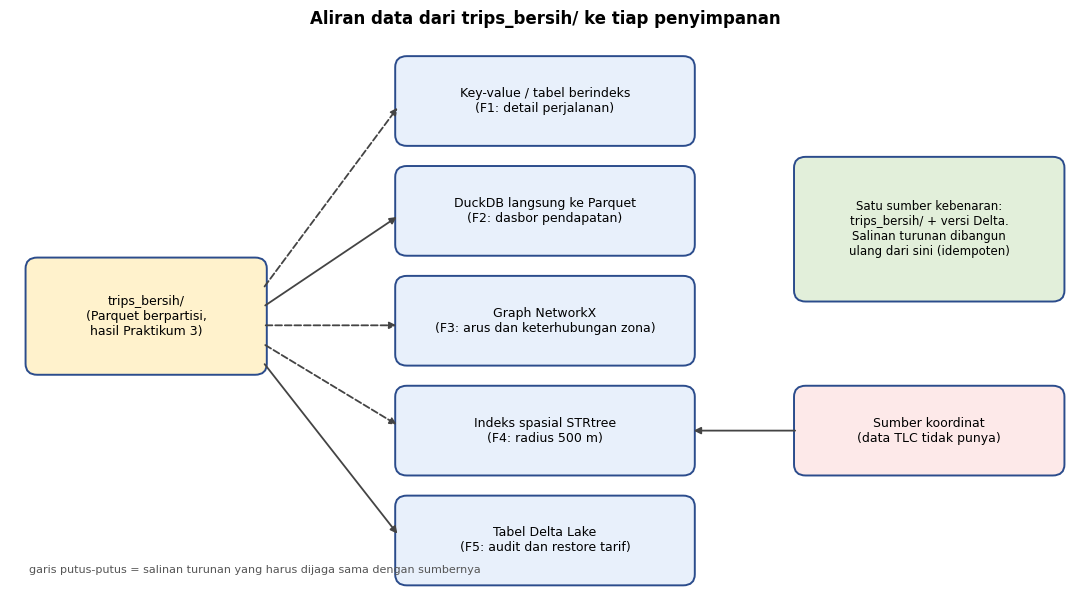

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 6.2))
ax.set_xlim(0, 11); ax.set_ylim(0, 6.2); ax.axis("off")

def kotak_(x, y, w, h, teks, warna, fs=9):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.04,rounding_size=0.12",
                                fc=warna, ec="#2b4c8c", lw=1.4))
    ax.text(x + w/2, y + h/2, teks, ha="center", va="center", fontsize=fs)

def panah(x1, y1, x2, y2, putus=False):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", lw=1.3, color="#444",
                                linestyle="--" if putus else "-"))

kotak_(0.2, 2.5, 2.4, 1.2, "trips_bersih/\n(Parquet berpartisi,\nhasil Praktikum 3)", "#fff2cc")
kotak_(4.0, 5.0, 3.0, 0.9, "Key-value / tabel berindeks\n(F1: detail perjalanan)", "#e8f0fb")
kotak_(4.0, 3.8, 3.0, 0.9, "DuckDB langsung ke Parquet\n(F2: dasbor pendapatan)", "#e8f0fb")
kotak_(4.0, 2.6, 3.0, 0.9, "Graph NetworkX\n(F3: arus dan keterhubungan zona)", "#e8f0fb")
kotak_(4.0, 1.4, 3.0, 0.9, "Indeks spasial STRtree\n(F4: radius 500 m)", "#e8f0fb")
kotak_(4.0, 0.2, 3.0, 0.9, "Tabel Delta Lake\n(F5: audit dan restore tarif)", "#e8f0fb")
kotak_(8.1, 1.4, 2.7, 0.9, "Sumber koordinat\n(data TLC tidak punya)", "#fde9e9")
kotak_(8.1, 3.3, 2.7, 1.5, "Satu sumber kebenaran:\ntrips_bersih/ + versi Delta.\nSalinan turunan dibangun\nulang dari sini (idempoten)", "#e2efda", fs=8.5)

panah(2.6, 3.4, 4.0, 5.4, putus=True)     # F1 salinan
panah(2.6, 3.2, 4.0, 4.2)                  # F2 langsung
panah(2.6, 3.0, 4.0, 3.0, putus=True)      # F3 turunan
panah(2.6, 2.8, 4.0, 1.9, putus=True)      # F4 salinan
panah(2.6, 2.6, 4.0, 0.7)                  # F5 tabel tarif
panah(8.1, 1.85, 7.0, 1.85)                # koordinat -> STRtree
ax.text(0.2, 0.3, "garis putus-putus = salinan turunan yang harus dijaga sama dengan sumbernya", fontsize=8, color="#555")
ax.set_title("Aliran data dari trips_bersih/ ke tiap penyimpanan", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/diagram_penyimpanan.png", dpi=150)
plt.show()

### **P-3. Data Ganda dan Cara Menjaganya Tetap Sama**

Bagian rancangan yang terpaksa menyimpan data ganda adalah fitur 1, 3, dan 4. Detail perjalanan di key-value adalah salinan baris yang juga ada di `trips_bersih/`; graph adalah ringkasan turunan dari perjalanan yang sama; dan indeks spasial memegang salinan titik lokasi.

Kedua salinan dijaga sama dengan tiga aturan. **(1)** Satu sumber kebenaran: perubahan hanya ditulis ke `trips_bersih/` (atau tabel Delta untuk tarif), dan semua salinan dibangun ulang darinya oleh pipeline yang idempoten, bukan diubah sendiri-sendiri. **(2)** Setiap salinan mencatat versi sumber yang dipakainya (mis. nomor versi Delta atau waktu pembangunan), sehingga salinan yang tertinggal mudah terdeteksi. **(3)** Setelah dibangun ulang, hasilnya diperiksa silang seperti pada K-4 dan K-5: jumlah baris dan total `total_bayar` harus sama dengan sumber, dan jawaban graph harus sama dengan jawaban SQL.

# **Latihan**


### **Latihan 1**

Mengulang pencarian K-2 dengan 2.000 id acak, hanya untuk tabel berindeks dan key-value, lalu menghitung waktu rata-rata per pencarian dalam mikrodetik (µs).

In [ ]:
random.seed(7)
id_uji_2k = random.sample(range(1, len(data) + 1), 2000)

def cari_sql_2k():
    cur = con.cursor()
    return [cur.execute("SELECT * FROM perjalanan WHERE id_perjalanan = ?", (i,)).fetchone() for i in id_uji_2k]

def cari_kv_2k():
    return [json.loads(kv[f"perjalanan:{i}"]) for i in id_uji_2k]

ukur("Latihan 1 - cari 2000 - SQL dengan indeks", cari_sql_2k)
t_sql_2k = catatan[-1]["detik"]
ukur("Latihan 1 - cari 2000 - key-value", cari_kv_2k)
t_kv_2k = catatan[-1]["detik"]
print(f"rata-rata per pencarian -> tabel berindeks: {t_sql_2k/2000*1e6:.1f} µs | key-value: {t_kv_2k/2000*1e6:.1f} µs")

[Latihan 1 - cari 2000 - SQL dengan indeks] 0.0374 s
[Latihan 1 - cari 2000 - key-value] 0.0110 s
rata-rata per pencarian -> tabel berindeks: 18.7 µs | key-value: 5.5 µs


### **Latihan 2**

Pada K-3, menghitung dokumen dengan zona tujuan tertentu dan `metode_bayar` "Tunai", lalu menghitung angka yang sama lewat SQL pada tabel K-2. Angka bisa berbeda karena tabel SQLite berisi 300.000 baris sedangkan document store hanya 20.000; perbandingan yang adil memakai himpunan baris yang sama (`id_perjalanan` 1–20.000).

In [ ]:
Z_TUJUAN = int(data["zona_tujuan"].value_counts().index[0])      # zona tujuan paling sering
n_doc = len(tabel.search((Q.tujuan.zona == Z_TUJUAN) & (Q.biaya.metode_bayar == "Tunai")))
n_sql_semua = con.execute(
    "SELECT COUNT(*) FROM perjalanan WHERE zona_tujuan = ? AND metode_bayar = 'Tunai'", (Z_TUJUAN,)).fetchone()[0]
n_sql_sama = con.execute(
    "SELECT COUNT(*) FROM perjalanan WHERE zona_tujuan = ? AND metode_bayar = 'Tunai' AND id_perjalanan <= 20000",
    (Z_TUJUAN,)).fetchone()[0]
print(f"zona tujuan {Z_TUJUAN} & Tunai -> document store (20.000 dokumen): {n_doc} | SQL seluruh tabel (300.000 baris): {n_sql_semua} | SQL pada 20.000 baris yang sama: {n_sql_sama}")
print("sama dengan document store bila himpunan barisnya disamakan?", n_doc == n_sql_sama)

zona tujuan 236 & Tunai -> document store (20.000 dokumen): 155 | SQL seluruh tabel (300.000 baris): 2074 | SQL pada 20.000 baris yang sama: 155
sama dengan document store bila himpunan barisnya disamakan? True


### **Latihan 3**

Pada K-4, menjalankan `SUM` atas satu kolom angka lalu `SUM` atas beberapa kolom sekaligus, di DuckDB (per kolom) dan SQLite (per baris). Setiap pengukuran diulang lima kali (median). Pada penyimpanan per kolom, biaya naik mengikuti jumlah kolom yang dibaca (*column pruning*); pada penyimpanan per baris, satu baris dibaca utuh sehingga jumlah kolom hampir tidak berpengaruh.

In [ ]:
SATU = "SELECT SUM(total_amount) FROM read_parquet('{g}', hive_partitioning=true)".format(g=GLOB)
BANYAK = ("SELECT SUM(fare_amount), SUM(tip_amount), SUM(total_amount), SUM(trip_distance), SUM(durasi_menit) "
          "FROM read_parquet('{g}', hive_partitioning=true)").format(g=GLOB)
d_satu = median_ulang(lambda: con_d.sql(SATU).fetchall())
d_banyak = median_ulang(lambda: con_d.sql(BANYAK).fetchall())

s_satu = median_ulang(lambda: con_s.execute("SELECT SUM(total_bayar) FROM perjalanan").fetchall())
s_banyak = median_ulang(lambda: con_s.execute(
    "SELECT SUM(total_bayar), SUM(jarak_mil), SUM(zona_jemput), SUM(zona_tujuan) FROM perjalanan").fetchall())

print(f"DuckDB (per kolom): 1 kolom {d_satu:.4f} s | 5 kolom {d_banyak:.4f} s | rasio banyak/satu = {d_banyak/d_satu:.2f}")
print(f"SQLite (per baris): 1 kolom {s_satu:.4f} s | 4 kolom {s_banyak:.4f} s | rasio banyak/satu = {s_banyak/s_satu:.2f}")

DuckDB (per kolom): 1 kolom 0.1967 s | 5 kolom 0.4017 s | rasio banyak/satu = 2.04
SQLite (per baris): 1 kolom 0.2553 s | 4 kolom 0.7377 s | rasio banyak/satu = 2.89


### **Latihan 4**

Pada K-5, mencari lima zona dengan jumlah zona tujuan *berbeda* terbanyak memakai graph (out-degree), lalu menyilangkannya dengan SQL `COUNT(DISTINCT tujuan)`. Urutan diberi pengurut tambahan (nomor zona) agar hasil kedua cara bisa dibandingkan persis.

In [ ]:
top_out_graf = sorted(G.out_degree(), key=lambda kv_: (-kv_[1], kv_[0]))[:5]
top_out_sql = con_d.sql("""
    SELECT asal, COUNT(DISTINCT tujuan) AS n_tujuan
    FROM arus GROUP BY asal ORDER BY n_tujuan DESC, asal LIMIT 5""").df()
print("graph (out-degree):", top_out_graf)
print("SQL (COUNT DISTINCT):", list(top_out_sql.itertuples(index=False, name=None)))
print("sama?", top_out_graf == [tuple(r) for r in top_out_sql.itertuples(index=False, name=None)])

graph (out-degree): [(132, 260), (138, 254), (264, 241), (230, 234), (140, 233)]
SQL (COUNT DISTINCT): [(132, 260), (138, 254), (264, 241), (230, 234), (140, 233)]
sama? True


### **Latihan 5**

Pada K-6, mengulang pengukuran dengan sisi kotak 0,02 derajat dan 0,001 derajat (K-6 memakai sisi 0,01). Tiap ukuran: NumPy untuk 1.000 kotak dan STRtree (indeks sudah dibangun) untuk 1.000 kotak. Kotak yang lebih kecil menyisakan lebih sedikit kandidat bagi indeks, sedangkan NumPy tetap memeriksa seluruh 200.000 titik untuk setiap kotak.

In [ ]:
hasil_l5 = []
for sisi in (0.02, 0.01, 0.001):
    sp = sisi / 2
    kotak_s = [box(x - sp, y - sp, x + sp, y + sp) for x, y in zip(cx, cy)]
    def np_s():
        return [int(((bujur >= x - sp) & (bujur <= x + sp) & (lintang >= y - sp) & (lintang <= y + sp)).sum()) for x, y in zip(cx, cy)]
    ukur(f"Latihan 5 - NumPy sisi {sisi}", np_s)
    t_np_s = catatan[-1]["detik"]
    ukur(f"Latihan 5 - STRtree sisi {sisi}", lambda: [len(pohon.query(k, predicate="contains")) for k in kotak_s])
    t_ix_s = catatan[-1]["detik"]
    hasil_l5.append({"sisi_derajat": sisi, "numpy_s": t_np_s, "strtree_s": t_ix_s, "rasio_numpy/strtree": round(t_np_s / t_ix_s, 2)})
print(pd.DataFrame(hasil_l5).to_string(index=False))

[Latihan 5 - NumPy sisi 0.02] 0.6388 s
[Latihan 5 - STRtree sisi 0.02] 1.2048 s
[Latihan 5 - NumPy sisi 0.01] 0.7182 s
[Latihan 5 - STRtree sisi 0.01] 0.2399 s
[Latihan 5 - NumPy sisi 0.001] 0.5677 s
[Latihan 5 - STRtree sisi 0.001] 0.0130 s
 sisi_derajat  numpy_s  strtree_s  rasio_numpy/strtree
        0.020   0.6388     1.2048                 0.53
        0.010   0.7182     0.2399                 2.99
        0.001   0.5677     0.0130                43.67


### **Latihan 6**

Kode bawaan modul, dijalankan setelah K-8. `restore(1)` mengembalikan tabel ke keadaan versi 1 dengan menulis versi *baru* (bukan menghapus versi 2 dan seterusnya), sedangkan time travel hanya *membaca* versi lama tanpa mengubah tabel.

In [ ]:
dt = DeltaTable(PATH_DELTA)
print("versi sebelum restore:", dt.version(), "| baris:", len(dt.to_pandas()))
dt.restore(1)                        # kembalikan tabel ke keadaan versi 1 (dicatat sebagai versi baru)
dt = DeltaTable(PATH_DELTA)
print("versi setelah restore:", dt.version(), "| baris:", len(dt.to_pandas()))
print([h.get("operation") for h in dt.history()][:3])

versi sebelum restore: 23 | baris: 160000
versi setelah restore: 24 | baris: 150000
['RESTORE', 'OPTIMIZE', 'WRITE']


# **Tugas**

### **Tugas 1 - Rekap Benchmark**

Tabel rekap K-9 diisi dengan angka sendiri, lengkap dengan satu kalimat interpretasi untuk tiap baris. Isi tabel dihitung dari `catatan`, jadi ikut berubah bila notebook dijalankan ulang di komputer lain. Hasil disimpan ke `rekap_k9.csv`.

In [ ]:
def arah(a, b, nama_a, nama_b):
    return banding(a, b, nama_a, nama_b)

rekap_k9 = pd.DataFrame([
    {"Kebutuhan": "Ambil satu data lewat id",
     "Cara unggul": "Key-value; tabel dengan indeks", "Cara lemah": "Tabel tanpa indeks",
     "Angka Anda": f"tanpa indeks {waktu('cari 200 perjalanan - SQL tanpa indeks'):.4f} s | berindeks {waktu('cari 200 perjalanan - SQL dengan indeks'):.4f} s | key-value {waktu('cari 200 perjalanan - key-value'):.4f} s (200 pencarian)",
     "Interpretasi": arah(waktu('cari 200 perjalanan - SQL tanpa indeks'), waktu('cari 200 perjalanan - SQL dengan indeks'), "Tabel tanpa indeks", "tabel berindeks") + "; tabel berindeks dan key-value berada pada orde waktu yang sama."},
    {"Kebutuhan": "Menghitung atau merangkum banyak baris",
     "Cara unggul": "Per kolom (DuckDB pada Parquet)", "Cara lemah": "Key-value (buka semua nilai)",
     "Angka Anda": f"DuckDB {waktu('DuckDB - hitung per wilayah (langsung dari Parquet)'):.4f} s | SQLite {waktu('SQLite - hitung per wilayah'):.4f} s | SQL GROUP BY {waktu('hitung per wilayah - SQL GROUP BY'):.4f} s | key-value {waktu('hitung per wilayah - key-value (buka semua nilai)'):.4f} s",
     "Interpretasi": arah(waktu('hitung per wilayah - key-value (buka semua nilai)'), waktu('hitung per wilayah - SQL GROUP BY'), "Key-value", "SQL GROUP BY") + "; " + arah(waktu('SQLite - hitung per wilayah'), waktu('DuckDB - hitung per wilayah (langsung dari Parquet)'), "SQLite", "DuckDB") + "."},
    {"Kebutuhan": "Data dengan field opsional atau berubah-ubah",
     "Cara unggul": "Document", "Cara lemah": "Tabel (kolom NULL, migrasi)",
     "Angka Anda": "(kualitatif)",
     "Interpretasi": f"{n_notip:,} dari {n_total:,} dokumen tidak punya field tip dan satu dokumen membawa field cuaca tanpa migrasi, tetapi dokumen salah ketik pun tetap diterima karena tidak ada skema."},
    {"Kebutuhan": "Keterhubungan dengan jumlah langkah bebas",
     "Cara unggul": "Graph", "Cara lemah": "SQL (satu JOIN per langkah)",
     "Angka Anda": f"2 langkah: graph {waktu('2 langkah - graph (NetworkX)'):.4f} s | SQL self-join {waktu('2 langkah - SQL self-join (DuckDB)'):.4f} s",
     "Interpretasi": "Jawaban sama dan kecepatan sebanding; keunggulan graph ada pada cara bertanya: 'paling banyak k langkah' cukup mengganti angka k."},
    {"Kebutuhan": "Mencari lokasi dalam wilayah",
     "Cara unggul": "Spasial dengan indeks", "Cara lemah": "Memeriksa semua titik",
     "Angka Anda": f"loop (perkiraan 1000 kotak) {t_loop1000:.1f} s | NumPy {t_np:.4f} s | STRtree {t_bangun+t_cari:.4f} s",
     "Interpretasi": arah(t_np, t_bangun+t_cari, "NumPy", "STRtree (termasuk bangun indeks)") + f"; terhadap loop Python selisihnya sekitar {t_loop1000/(t_bangun+t_cari):,.0f} kali."},
    {"Kebutuhan": "Perubahan yang harus aman dan bisa dibatalkan",
     "Cara unggul": "Tabel Delta", "Cara lemah": "Folder Parquet biasa",
     "Angka Anda": "(kualitatif)",
     "Interpretasi": "Update, time travel, restore, dan penolakan kolom asing semuanya tercatat sebagai versi di _delta_log/, kemampuan yang tidak dimiliki folder Parquet biasa."},
])
rekap_k9.to_csv(f"{DIR_SIMPAN}/rekap_k9.csv", index=False)
for _, r in rekap_k9.iterrows():
    print(f"- {r['Kebutuhan']}\n    angka      : {r['Angka Anda']}\n    interpretasi: {r['Interpretasi']}")

- Ambil satu data lewat id
    angka      : tanpa indeks 9.3578 s | berindeks 0.0037 s | key-value 0.0013 s (200 pencarian)
    interpretasi: Tabel tanpa indeks 2529.1 kali lebih lambat daripada tabel berindeks; tabel berindeks dan key-value berada pada orde waktu yang sama.
- Menghitung atau merangkum banyak baris
    angka      : DuckDB 0.2551 s | SQLite 2.7871 s | SQL GROUP BY 0.2021 s | key-value 1.3054 s
    interpretasi: Key-value 6.5 kali lebih lambat daripada SQL GROUP BY; SQLite 10.9 kali lebih lambat daripada DuckDB.
- Data dengan field opsional atau berubah-ubah
    angka      : (kualitatif)
    interpretasi: 4,094 dari 20,001 dokumen tidak punya field tip dan satu dokumen membawa field cuaca tanpa migrasi, tetapi dokumen salah ketik pun tetap diterima karena tidak ada skema.
- Keterhubungan dengan jumlah langkah bebas
    angka      : 2 langkah: graph 0.0071 s | SQL self-join 0.0076 s
    interpretasi: Jawaban sama dan kecepatan sebanding; keunggulan graph ada pada cara ber

### **Tugas 2 - Data Lain: Zona**

Data lain yang dipilih adalah **zona** (nomor zona, wilayahnya, jumlah penjemputan, dan arus ke zona tujuan). Dirancang tiga cara menyimpannya: tabel SQLite (`zona` dan `arus_zona`), dokumen TinyDB (satu dokumen per zona dengan lima tujuan teratas tertanam), dan graph NetworkX. Untuk masing-masing dijalankan satu pertanyaan yang mudah dan satu yang canggung dijawab.

In [ ]:
# Data zona diturunkan dari data perjalanan yang sama
zona_info = con_d.sql("""
    SELECT zona_jemput AS zona, MIN(wilayah_jemput) AS wilayah, COUNT(*) AS jumlah_jemput
    FROM perjalanan GROUP BY zona_jemput ORDER BY zona_jemput""").df()
Z = int(zona_awal)          # zona contoh: tujuan terpopuler pada K-5

# --- Cara 1: tabel (SQLite) ---
con_z = sqlite3.connect(":memory:")
zona_info.to_sql("zona", con_z, index=False)
arus.to_sql("arus_zona", con_z, index=False)
con_z.execute("CREATE INDEX idx_asal ON arus_zona(asal)")
t1_mudah = ukur("T2 tabel - MUDAH: wilayah dan jumlah jemput satu zona",
                lambda: con_z.execute("SELECT * FROM zona WHERE zona = ?", (Z,)).fetchall())
t1_susah = ukur("T2 tabel - CANGGUNG: zona dalam 3 langkah (2 self-join)", lambda: con_z.execute(f"""
    SELECT DISTINCT a3.tujuan FROM arus_zona a1
    JOIN arus_zona a2 ON a1.tujuan = a2.asal JOIN arus_zona a3 ON a2.tujuan = a3.asal
    WHERE a1.asal = {Z} AND a1.jumlah >= {MIN} AND a2.jumlah >= {MIN} AND a3.jumlah >= {MIN}""").fetchall())

# --- Cara 2: dokumen (TinyDB), lima tujuan teratas tertanam di tiap dokumen ---
db_z = TinyDB(storage=MemoryStorage)
tab_z = db_z.table("zona")
top5 = (arus.sort_values(["asal", "jumlah", "tujuan"], ascending=[True, False, True]).groupby("asal").head(5))
tujuan_tertanam = {a: [{"zona": int(t), "jumlah": int(j)} for t, j in zip(g["tujuan"], g["jumlah"])]
                   for a, g in top5.groupby("asal")}
tab_z.insert_multiple([{"zona": int(r.zona), "wilayah": r.wilayah, "jumlah_jemput": int(r.jumlah_jemput),
                        "tujuan_teratas": tujuan_tertanam.get(int(r.zona), [])} for r in zona_info.itertuples()])
t2_mudah = ukur("T2 dokumen - MUDAH: satu dokumen zona lengkap", lambda: tab_z.search(Q.zona == Z))
def dokumen_susah():   # tujuan terbesar dari seluruh zona di wilayah tertentu: harus memindai dokumen dan hanya melihat top-5
    wil = zona_info["wilayah"].mode().iloc[0]
    total = {}
    for d_ in tab_z.search(Q.wilayah == wil):
        for t in d_["tujuan_teratas"]:
            total[t["zona"]] = total.get(t["zona"], 0) + t["jumlah"]
    return wil, sorted(total.items(), key=lambda kv_: (-kv_[1], kv_[0]))[:3]
t2_susah = ukur("T2 dokumen - CANGGUNG: tujuan terbesar dari satu wilayah", dokumen_susah)

# --- Cara 3: graph (NetworkX), zona = node dengan atribut ---
for r in zona_info.itertuples():
    G.nodes[int(r.zona)]["wilayah"] = r.wilayah
    G.nodes[int(r.zona)]["jumlah_jemput"] = int(r.jumlah_jemput)
t3_mudah = ukur("T2 graph - MUDAH: zona dalam 3 langkah", lambda: len(nx.single_source_shortest_path_length(H, Z, cutoff=3)) - 1)
t3_susah = "tidak bisa: graph tidak menyimpan total_bayar, hanya jumlah arus"

print("\nTabel   - mudah:", f"{t1_mudah!r:.60}", "| canggung (3 langkah):", len(t1_susah), "zona")
print("Dokumen - mudah: 1 dokumen,", len(t2_mudah[0]["tujuan_teratas"]), "tujuan tertanam | canggung:", t2_susah[0], t2_susah[1], "(hanya dari top-5 per zona, jadi hasilnya hanya perkiraan)")
print("Graph   - mudah:", t3_mudah, "zona dalam <=3 langkah | canggung: rata-rata total_bayar per wilayah ->", t3_susah)

[T2 tabel - MUDAH: wilayah dan jumlah jemput satu zona] 0.0001 s
[T2 tabel - CANGGUNG: zona dalam 3 langkah (2 self-join)] 0.2646 s
[T2 dokumen - MUDAH: satu dokumen zona lengkap] 0.0003 s
[T2 dokumen - CANGGUNG: tujuan terbesar dari satu wilayah] 0.0016 s
[T2 graph - MUDAH: zona dalam 3 langkah] 0.0003 s

Tabel   - mudah: [(236, 'Manhattan', 136276)] | canggung (3 langkah): 215 zona
Dokumen - mudah: 1 dokumen, 5 tujuan tertanam | canggung: Queens [(230, 11933), (48, 6671), (265, 5052)] (hanya dari top-5 per zona, jadi hasilnya hanya perkiraan)
Graph   - mudah: 214 zona dalam <=3 langkah | canggung: rata-rata total_bayar per wilayah -> tidak bisa: graph tidak menyimpan total_bayar, hanya jumlah arus


### **Tugas 3 - Delta Lake Dua Hari**

Simulasi dua hari kerja pada tabel Delta baru (`trips_delta_2hari`). Hari pertama menulis sebagian data; hari kedua menambah data dan mengoreksi beberapa baris. Lalu tabel dibaca *seperti keadaannya di akhir hari pertama* lewat time travel, dan isi `_delta_log/` dicetak per versi. Terakhir folder `trips_delta/` (K-7 dan K-8) diarsipkan menjadi `trips_delta.zip` sebagai berkas yang dikumpulkan.

In [ ]:
PATH_DELTA_2H = "/content/trips_delta_2hari"   # disk lokal Colab (Drive tidak mendukung rename yang dipakai Delta)
if os.path.exists(PATH_DELTA_2H):
    shutil.rmtree(PATH_DELTA_2H)

# HARI 1: menulis sebagian data
hari1 = data_delta.iloc[:60_000]
write_deltalake(PATH_DELTA_2H, hari1, mode="overwrite")
versi_akhir_hari1 = DeltaTable(PATH_DELTA_2H).version()
print("akhir hari 1 -> versi:", versi_akhir_hari1, "| baris:", len(hari1))

# HARI 2: menambah data, lalu mengoreksi beberapa baris
write_deltalake(PATH_DELTA_2H, data_delta.iloc[60_000:90_000], mode="append")
dt2 = DeltaTable(PATH_DELTA_2H)
n_koreksi2 = int(((data_delta.iloc[:90_000]["wilayah_jemput"] == "Queens") & (data_delta.iloc[:90_000]["metode_bayar"] == "Tunai")).sum())
dt2.update(predicate="wilayah_jemput = 'Queens' AND metode_bayar = 'Tunai'", updates={"total_bayar": "total_bayar + 0.5"})
dt2 = DeltaTable(PATH_DELTA_2H)
print("akhir hari 2 -> versi:", dt2.version(), "| baris:", len(dt2.to_pandas()), "| baris dikoreksi:", n_koreksi2)

# Membaca tabel seperti keadaannya di akhir hari pertama
akhir_hari1 = DeltaTable(PATH_DELTA_2H, version=versi_akhir_hari1).to_pandas()
print("tabel pada akhir hari 1:", len(akhir_hari1), "baris | total_bayar sama dengan data hari 1?",
      round(akhir_hari1["total_bayar"].sum(), 2) == round(hari1["total_bayar"].sum(), 2))

# Isi _delta_log/: satu berkas JSON per versi
LOG = f"{PATH_DELTA_2H}/_delta_log"
for nama_log in sorted(os.listdir(LOG)):
    isi = [json.loads(b) for b in open(os.path.join(LOG, nama_log)) if b.strip()]
    jenis = [list(x.keys())[0] for x in isi]
    op = next((x["commitInfo"].get("operation") for x in isi if "commitInfo" in x), "-")
    print(f"{nama_log}: operasi={op} | add={jenis.count('add')} remove={jenis.count('remove')} | entri={jenis}")

# Arsip folder trips_delta/ untuk dikumpulkan
shutil.make_archive(f"{DIR_SIMPAN}/trips_delta", "zip", PATH_DELTA)
print("arsip tersimpan:", f"{DIR_SIMPAN}/trips_delta.zip", f"({os.path.getsize(f'{DIR_SIMPAN}/trips_delta.zip')/1024**2:.1f} MB)")

akhir hari 1 -> versi: 0 | baris: 60000
akhir hari 2 -> versi: 2 | baris: 90000 | baris dikoreksi: 1851
tabel pada akhir hari 1: 60000 baris | total_bayar sama dengan data hari 1? True
00000000000000000000.json: operasi=WRITE | add=1 remove=0 | entri=['commitInfo', 'protocol', 'metaData', 'add']
00000000000000000001.json: operasi=WRITE | add=1 remove=0 | entri=['commitInfo', 'add']
00000000000000000002.json: operasi=UPDATE | add=1 remove=2 | entri=['commitInfo', 'add', 'remove', 'remove']
arsip tersimpan: /content/drive/MyDrive/BigData/Praktikum4/trips_delta.zip (5.7 MB)


### **Tugas 4 - Laporan dan Pemeriksaan Reproducibility**

Laporan rancangan penyimpanan untuk studi kasus (Bagian P) disusun pada laporan praktikum. Sel ini memeriksa bahwa semua berkas yang dikumpulkan sudah ada di Drive. Sebelum notebook dikumpulkan, jalankan **Restart and run all** pada runtime yang bersih; keluaran sel ini baru bermakna bila seluruh sel di atasnya dijalankan berurutan.

In [ ]:
artefak_wajib = ["benchmark_nosql.csv", "rekap_k9.csv", "rancangan_penyimpanan.csv",
                 "diagram_penyimpanan.png", "trips_delta.zip"]
semua_ada = True
for nama in artefak_wajib:
    p = os.path.join(DIR_SIMPAN, nama)
    ada = os.path.exists(p) and os.path.getsize(p) > 0
    print(f"  {'OK    ' if ada else 'HILANG'} {nama:28s} ({(os.path.getsize(p)/1024 if ada else 0):.1f} KB)")
    semua_ada = semua_ada and ada
print("folder trips_delta_2hari ada?", os.path.isdir("/content/trips_delta_2hari"))
print("Semua berkas yang dikumpulkan lengkap?", semua_ada)

  OK     benchmark_nosql.csv          (0.7 KB)
  OK     rekap_k9.csv                 (1.6 KB)
  OK     rancangan_penyimpanan.csv    (1.6 KB)
  OK     diagram_penyimpanan.png      (135.0 KB)
  OK     trips_delta.zip              (5858.5 KB)
folder trips_delta_2hari ada? True
Semua berkas yang dikumpulkan lengkap? True
